# Notebook 3 — Génération du Biais Inductif

**Objectif :** Fusionner les 8 métriques IQA du Notebook 2 en un **score unique $c \in [0, 1]$**  
interprétable par le cVAE (1 = très bonne qualité, 0 = image très dégradée).

**Deux méthodes comparées :**

| Méthode | Principe | Avantage |
|---|---|---|
| **A — Score pondéré** | Combinaison linéaire des métriques normalisées | Interprétable physiquement |
| **B — PCA (PC1)** | Premier composant principal = direction de variance maximale | Objectif, pas de choix arbitraire de poids |

**Livrable :** `outputs/labels_quality.csv` — pont vers le cVAE (Notebooks 4 & 5).

## 0. Configuration

In [19]:
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Entrées (produites par le Notebook 2)
CSV_METRICS    = OUTPUT_DIR / "patch_metrics_full.csv"
RESNET_NPY     = OUTPUT_DIR / "resnet18_features.npy"
RESNET_IDS_CSV = OUTPUT_DIR / "resnet18_ids.csv"
QMAPS_DIR      = OUTPUT_DIR / "quality_maps"

# Sortie principale
OUT_LABELS_CSV = OUTPUT_DIR / "labels_quality.csv"

# Poids pour la Méthode A (somme = 1.0)
# Justification : tenengrad est la métrique la plus discriminante sur DSA
WEIGHTS = {
    "tenengrad":   0.30,
    "laplacian_var": 0.25,
    "rms_contrast": 0.15,
    "entropy_inv": 0.15,   # entropie inversée : haute entropie = mauvaise qualité
    "spatial_homogeneity": 0.10,  # feature engineerée (section 4)
    "directional_balance": 0.05,  # feature engineerée (section 4)
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9

print(f"Entrée métriques : {CSV_METRICS}")
print(f"Sortie labels    : {OUT_LABELS_CSV}")

Entrée métriques : outputs\patch_metrics_full.csv
Sortie labels    : outputs\labels_quality.csv


## 1. Imports

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Imports OK")

Imports OK


## 2. Chargement des métriques (sortie Notebook 2)

In [21]:
df_raw = pd.read_csv(CSV_METRICS)
print(f"Dataset chargé : {len(df_raw)} lignes, {len(df_raw.columns)} colonnes")
print(f"Colonnes disponibles :\n{list(df_raw.columns)}")

Dataset chargé : 1200 lignes, 18 colonnes
Colonnes disponibles :
['image_id', 'path', 'laplacian_var_mean', 'laplacian_var_std', 'rms_contrast_mean', 'rms_contrast_std', 'entropy_mean', 'entropy_std', 'tenengrad_mean', 'tenengrad_std', 'ten_H_mean', 'ten_H_std', 'ten_V_mean', 'ten_V_std', 'ten_D1_mean', 'ten_D1_std', 'ten_D2_mean', 'ten_D2_std']


## 3. Nettoyage et inspection

In [22]:
# Colonnes de métriques (moyennes par image)
MEAN_COLS = [c for c in df_raw.columns if c.endswith("_mean")]
STD_COLS  = [c for c in df_raw.columns if c.endswith("_std")]

print(f"Métriques (_mean) : {MEAN_COLS}")
print(f"\nValeurs manquantes :")
print(df_raw[MEAN_COLS].isna().sum())

# Suppression des lignes avec erreurs de traitement
n_before = len(df_raw)
df = df_raw.dropna(subset=MEAN_COLS).copy().reset_index(drop=True)
print(f"\nImages conservées : {len(df)} / {n_before}  ({n_before - len(df)} supprimées)")

Métriques (_mean) : ['laplacian_var_mean', 'rms_contrast_mean', 'entropy_mean', 'tenengrad_mean', 'ten_H_mean', 'ten_V_mean', 'ten_D1_mean', 'ten_D2_mean']

Valeurs manquantes :
laplacian_var_mean    0
rms_contrast_mean     0
entropy_mean          0
tenengrad_mean        0
ten_H_mean            0
ten_V_mean            0
ten_D1_mean           0
ten_D2_mean           0
dtype: int64

Images conservées : 1200 / 1200  (0 supprimées)


In [23]:
# Inspection des outliers (> 3σ)
print("Outliers (> 3σ) par métrique :")
for col in MEAN_COLS:
    z = np.abs((df[col] - df[col].mean()) / df[col].std())
    n_out = (z > 3).sum()
    if n_out > 0:
        print(f"  {col:30s} → {n_out} outliers")

# On garde les outliers : ils représentent les images vraiment dégradées
# que l'on veut distinguer. On les clippe à 1er/99e percentile pour
# ne pas perturber la normalisation Min-Max.
df_clipped = df.copy()
for col in MEAN_COLS:
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    df_clipped[col] = df[col].clip(lo, hi)

print("\nClipping [1%, 99%] appliqué.")

Outliers (> 3σ) par métrique :
  laplacian_var_mean             → 3 outliers
  rms_contrast_mean              → 1 outliers
  entropy_mean                   → 39 outliers
  tenengrad_mean                 → 1 outliers
  ten_H_mean                     → 2 outliers
  ten_V_mean                     → 1 outliers
  ten_D1_mean                    → 2 outliers
  ten_D2_mean                    → 2 outliers

Clipping [1%, 99%] appliqué.


## 4. Feature Engineering : deux indicateurs spatiaux

Les colonnes `*_std` du Notebook 2 encodent la **dispersion spatiale** de chaque métrique à travers les patchs.  
On en dérive deux indicateurs supplémentaires :

| Feature engineerée | Définition | Interprétation |
|---|---|---|
| `spatial_homogeneity` | $1 - \sigma_{\text{tenengrad}} / (\mu_{\text{tenengrad}} + \varepsilon)$ | 1 = qualité uniforme, 0 = zones floues locales |
| `directional_balance` | $\min(H, V, D_1, D_2) / (\max(H, V, D_1, D_2) + \varepsilon)$ | 1 = isotrope, 0 = flou directionnel (mouvement) |

In [24]:
EPS = 1e-8

# spatial_homogeneity : coefficient de variation inversé du tenengrad par patch
df_clipped["spatial_homogeneity"] = (
    1.0 - df_clipped["tenengrad_std"] / (df_clipped["tenengrad_mean"] + EPS)
).clip(0.0, 1.0)

# directional_balance : rapport min/max des 4 Tenengrad directionnels
dir_cols = ["ten_H_mean", "ten_V_mean", "ten_D1_mean", "ten_D2_mean"]
df_clipped["directional_balance"] = (
    df_clipped[dir_cols].min(axis=1) /
    (df_clipped[dir_cols].max(axis=1) + EPS)
).clip(0.0, 1.0)

print("Features engineerées :")
print(df_clipped[["spatial_homogeneity", "directional_balance"]].describe().round(4))

Features engineerées :
       spatial_homogeneity  directional_balance
count            1200.0000            1200.0000
mean                0.8536               0.9196
std                 0.0669               0.0411
min                 0.4101               0.7267
25%                 0.8247               0.8910
50%                 0.8630               0.9219
75%                 0.8970               0.9558
max                 0.9716               0.9981


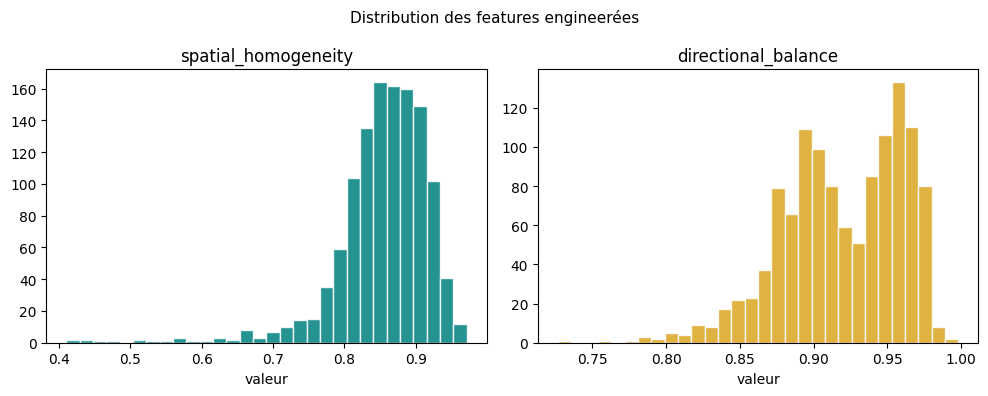

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, color in zip(axes,
                           ["spatial_homogeneity", "directional_balance"],
                           ["teal", "goldenrod"]):
    ax.hist(df_clipped[col], bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel("valeur")
fig.suptitle("Distribution des features engineerées", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_engineered_features.png", dpi=100, bbox_inches="tight")
plt.show()

## 5. Matrice de features finale

On sélectionne les features pertinentes et on **inverse l'entropie**  
(haute entropie = désordre = mauvaise qualité → on veut que toutes les features pointent dans la même direction).

In [26]:
# Entropie inversée : plus c'est haut, plus c'est propre
df_clipped["entropy_inv"] = df_clipped["entropy_mean"].max() - df_clipped["entropy_mean"]

# Features retenues pour le score composite
FEATURE_COLS = [
    "laplacian_var_mean",
    "rms_contrast_mean",
    "entropy_inv",          # inversée
    "tenengrad_mean",
    "spatial_homogeneity",
    "directional_balance",
]

X_raw = df_clipped[FEATURE_COLS].values.astype(np.float32)
print(f"Matrice X : {X_raw.shape}  ({len(FEATURE_COLS)} features × {len(df_clipped)} images)")
print(f"Features  : {FEATURE_COLS}")

Matrice X : (1200, 6)  (6 features × 1200 images)
Features  : ['laplacian_var_mean', 'rms_contrast_mean', 'entropy_inv', 'tenengrad_mean', 'spatial_homogeneity', 'directional_balance']


## 6. Méthode A — Score pondéré (physique du signal)

Chaque feature est normalisée à [0, 1] via Min-Max, puis combinée avec les poids définis en section 0.

In [27]:
# Normalisation Min-Max
scaler_minmax = MinMaxScaler()
X_norm = scaler_minmax.fit_transform(X_raw)  # (N, 6) dans [0,1]

# Mapping feature → poids (même ordre que FEATURE_COLS)
weight_vector = np.array([
    WEIGHTS["laplacian_var"],
    WEIGHTS["rms_contrast"],
    WEIGHTS["entropy_inv"],
    WEIGHTS["tenengrad"],
    WEIGHTS["spatial_homogeneity"],
    WEIGHTS["directional_balance"],
], dtype=np.float32)

score_A = (X_norm * weight_vector).sum(axis=1)  # (N,) dans [0,1]

df_clipped["score_weighted"] = score_A

print(f"Score pondéré — min={score_A.min():.4f}  max={score_A.max():.4f}  mean={score_A.mean():.4f}")

Score pondéré — min=0.1058  max=0.8146  mean=0.4204


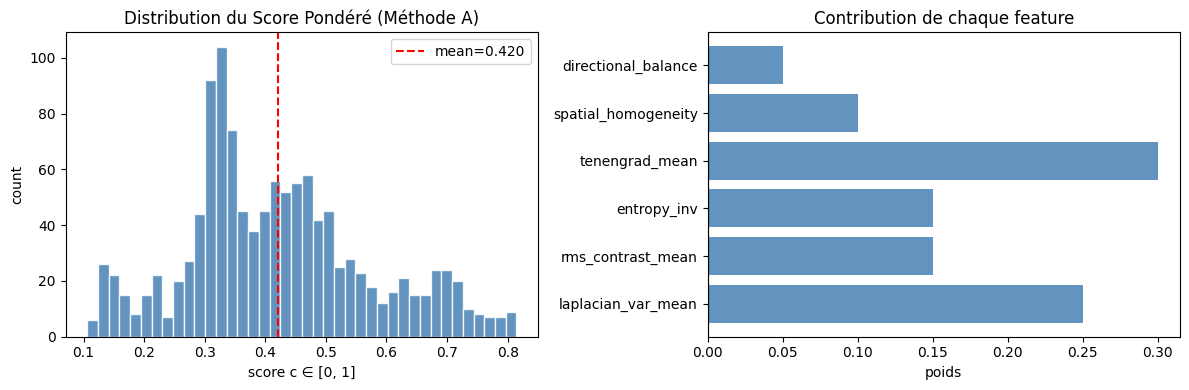

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(score_A, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution du Score Pondéré (Méthode A)")
axes[0].set_xlabel("score c ∈ [0, 1]")
axes[0].set_ylabel("count")
axes[0].axvline(score_A.mean(), color="red", lw=1.5, ls="--", label=f"mean={score_A.mean():.3f}")
axes[0].legend()

# Contribution de chaque feature
axes[1].barh(FEATURE_COLS, weight_vector, color="steelblue", alpha=0.85)
axes[1].set_xlabel("poids")
axes[1].set_title("Contribution de chaque feature")
axes[1].axvline(0, color="black", lw=0.8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_score_weighted.png", dpi=100, bbox_inches="tight")
plt.show()

## 7. Méthode B — Premier composant principal (PCA)

La PCA cherche la direction de **variance maximale** dans l'espace des features.  
Si nos métriques sont cohérentes, le PC1 devrait correspondre à l'axe de qualité.

> **Attention au signe :** la PCA ne garantit pas que PC1 > 0 = bonne qualité.  
> On vérifie la corrélation de PC1 avec le Tenengrad et on flip si nécessaire.

In [29]:
# Standardisation (obligatoire avant PCA)
scaler_std = StandardScaler()
X_std      = scaler_std.fit_transform(X_raw)  # (N, 6)

pca = PCA(n_components=min(6, X_std.shape[1]))
pca.fit(X_std)

print("Variance expliquée par composant :")
for i, r in enumerate(pca.explained_variance_ratio_):
    cumul = pca.explained_variance_ratio_[:i+1].sum()
    print(f"  PC{i+1} : {r*100:5.1f}%   (cumulé : {cumul*100:5.1f}%)")

Variance expliquée par composant :
  PC1 :  52.0%   (cumulé :  52.0%)
  PC2 :  29.8%   (cumulé :  81.8%)
  PC3 :   9.2%   (cumulé :  91.0%)
  PC4 :   6.6%   (cumulé :  97.7%)
  PC5 :   1.7%   (cumulé :  99.4%)
  PC6 :   0.6%   (cumulé : 100.0%)


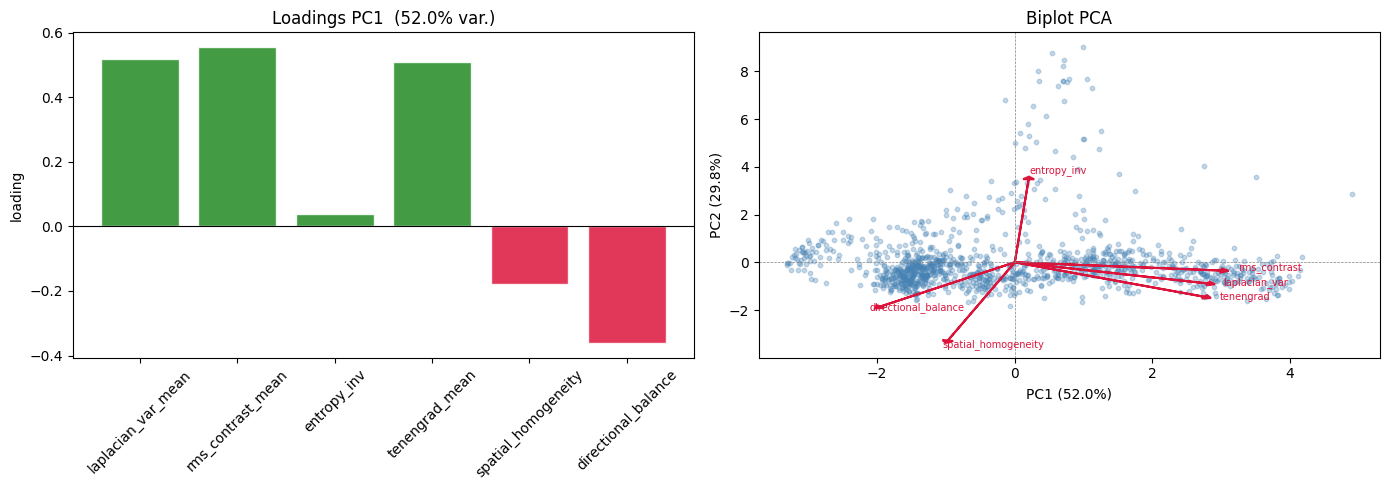

In [30]:
# Biplot : contribution de chaque feature au PC1 et PC2
components = pca.components_  # (n_components, n_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot des loadings PC1
colors_bar = ["forestgreen" if v > 0 else "crimson" for v in components[0]]
axes[0].bar(FEATURE_COLS, components[0], color=colors_bar, edgecolor="white", alpha=0.85)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title(f"Loadings PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
axes[0].set_ylabel("loading")
axes[0].tick_params(axis="x", rotation=45)

# Biplot PC1 vs PC2
coords = pca.transform(X_std)
axes[1].scatter(coords[:, 0], coords[:, 1], alpha=0.3, s=10, color="steelblue")
scale = np.abs(coords[:, :2]).max() * 0.6
for feat, (c1, c2) in zip(FEATURE_COLS, zip(components[0], components[1])):
    axes[1].arrow(0, 0, c1 * scale, c2 * scale,
                  head_width=scale*0.03, head_length=scale*0.02,
                  fc="crimson", ec="crimson", lw=1.5)
    axes[1].text(c1 * scale * 1.08, c2 * scale * 1.08,
                 feat.replace("_mean", ""), fontsize=7, color="crimson")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Biplot PCA")
axes[1].axhline(0, color="grey", lw=0.5, ls="--")
axes[1].axvline(0, color="grey", lw=0.5, ls="--")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_pca_biplot.png", dpi=120, bbox_inches="tight")
plt.show()

In [31]:
# Extraire PC1 et corriger son signe
pc1_raw = coords[:, 0]

# Corrélation de PC1 avec tenengrad_mean (référence qualité)
corr_with_tenengrad = np.corrcoef(pc1_raw, df_clipped["tenengrad_mean"].values)[0, 1]
print(f"Corrélation PC1 ↔ tenengrad_mean : {corr_with_tenengrad:+.4f}")

if corr_with_tenengrad < 0:
    pc1_raw = -pc1_raw
    print("→ Signe de PC1 inversé pour que score élevé = bonne qualité")
else:
    print("→ Signe de PC1 correct")

# Normalisation Min-Max → [0, 1]
pc1_min, pc1_max = pc1_raw.min(), pc1_raw.max()
score_B = (pc1_raw - pc1_min) / (pc1_max - pc1_min + EPS)

df_clipped["score_pca"] = score_B

print(f"Score PCA — min={score_B.min():.4f}  max={score_B.max():.4f}  mean={score_B.mean():.4f}")

Corrélation PC1 ↔ tenengrad_mean : +0.8993
→ Signe de PC1 correct
Score PCA — min=0.0000  max=1.0000  mean=0.4034


## 8. Comparaison Méthode A vs Méthode B

Corrélation Score A ↔ Score B : 0.9454


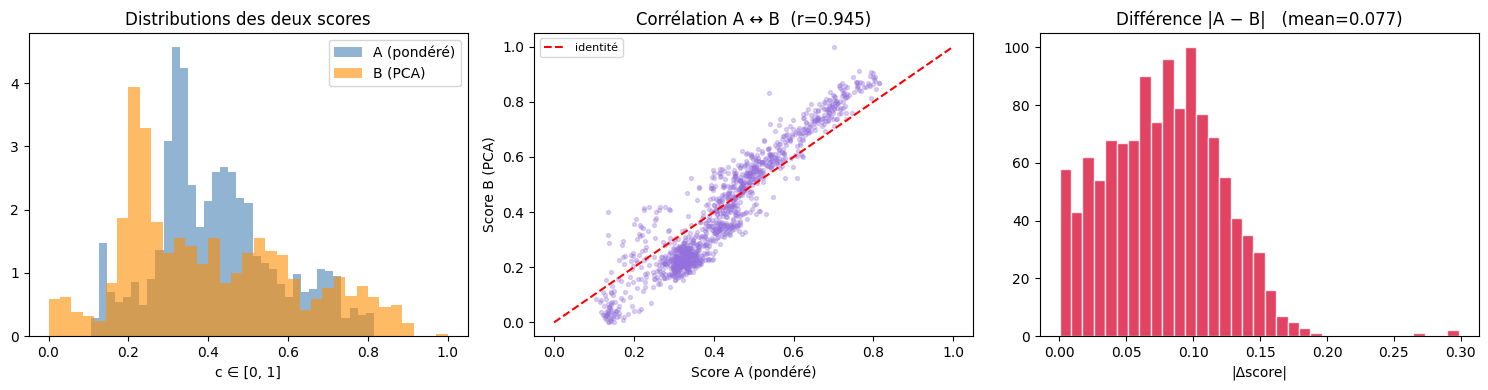

In [32]:
corr_AB = np.corrcoef(score_A, score_B)[0, 1]
print(f"Corrélation Score A ↔ Score B : {corr_AB:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distributions
axes[0].hist(score_A, bins=35, alpha=0.6, color="steelblue", label="A (pondéré)",  density=True)
axes[0].hist(score_B, bins=35, alpha=0.6, color="darkorange", label="B (PCA)",     density=True)
axes[0].set_title("Distributions des deux scores")
axes[0].set_xlabel("c ∈ [0, 1]")
axes[0].legend()

# Scatter A vs B
axes[1].scatter(score_A, score_B, alpha=0.3, s=8, color="mediumpurple")
lo, hi = min(score_A.min(), score_B.min()), max(score_A.max(), score_B.max())
axes[1].plot([lo, hi], [lo, hi], "r--", lw=1.5, label="identité")
axes[1].set_xlabel("Score A (pondéré)")
axes[1].set_ylabel("Score B (PCA)")
axes[1].set_title(f"Corrélation A ↔ B  (r={corr_AB:.3f})")
axes[1].legend(fontsize=8)

# Différence absolue
diff = np.abs(score_A - score_B)
axes[2].hist(diff, bins=35, color="crimson", edgecolor="white", alpha=0.8)
axes[2].set_title(f"Différence |A − B|   (mean={diff.mean():.3f})")
axes[2].set_xlabel("|Δscore|")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_score_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

In [33]:
# Images où les deux méthodes divergent le plus → cas ambigus
df_clipped["score_disagreement"] = diff
top_disagreement = df_clipped.nlargest(5, "score_disagreement")[["image_id", "score_weighted", "score_pca", "score_disagreement"]]
print("Images les plus ambiguës (désaccord A vs B) :")
print(top_disagreement.to_string(index=False))

Images les plus ambiguës (désaccord A vs B) :
 image_id  score_weighted  score_pca  score_disagreement
      662        0.701435   1.000000            0.298565
      645        0.538900   0.830834            0.291934
      171        0.135932   0.401452            0.265520
      171        0.224139   0.414357            0.190218
      686        0.342336   0.524717            0.182381


## 9. [Optionnel] Enrichissement avec les features ResNet-18

Si les features ResNet-18 ont été extraites dans le Notebook 2, on peut calculer un score PCA dans cet espace  
et le **moyenner** avec le score B pour un biais inductif plus riche.

In [34]:
USE_RESNET_SCORE = RESNET_NPY.exists() and RESNET_IDS_CSV.exists()

if USE_RESNET_SCORE:
    feat_arr  = np.load(RESNET_NPY)                                  # (N_feat, 512)
    feat_ids  = pd.read_csv(RESNET_IDS_CSV)["image_id"].tolist()     # N_feat

    # Réduire 512 → 1 dimension (PC1 dans l'espace ResNet)
    pca_rn = PCA(n_components=1)
    pc1_rn = pca_rn.fit_transform(StandardScaler().fit_transform(feat_arr)).squeeze()

    # Corriger le signe : corrélation avec tenengrad
    feat_ids_to_score = dict(zip(feat_ids, pc1_rn))
    rn_scores = np.array([feat_ids_to_score.get(iid, np.nan) for iid in df_clipped["image_id"]])

    valid_mask = ~np.isnan(rn_scores)
    corr_rn = np.corrcoef(rn_scores[valid_mask],
                          df_clipped["tenengrad_mean"].values[valid_mask])[0, 1]
    if corr_rn < 0:
        rn_scores = -rn_scores

    # Normalisation → [0, 1]
    rn_min, rn_max = np.nanmin(rn_scores), np.nanmax(rn_scores)
    score_RN = (rn_scores - rn_min) / (rn_max - rn_min + EPS)
    df_clipped["score_resnet"] = score_RN

    print(f"Score ResNet — varexp={pca_rn.explained_variance_ratio_[0]*100:.1f}%  "
          f"corr_tenengrad={corr_rn:+.4f}")

    # Score hybride = moyenne des 3 scores
    df_clipped["score_hybrid"] = np.nanmean(
        np.stack([score_A, score_B, score_RN], axis=1), axis=1
    )
    print(f"Score hybride (A+B+ResNet) — mean={df_clipped['score_hybrid'].mean():.4f}")
else:
    print("Fichiers ResNet introuvables — section ignorée.")
    df_clipped["score_resnet"] = np.nan
    df_clipped["score_hybrid"] = np.nan

Score ResNet — varexp=11.4%  corr_tenengrad=+0.2906
Score hybride (A+B+ResNet) — mean=0.4664


## 10. Choix du score final

**Règle de décision :**
- Si `score_hybrid` est disponible (ResNet activé) → utiliser `score_hybrid`  
- Sinon, si corrélation A↔B > 0.85 → utiliser `score_pca` (objectif, data-driven)  
- Sinon → utiliser `score_weighted` (plus robuste si peu d'images)

In [35]:
if USE_RESNET_SCORE and not df_clipped["score_hybrid"].isna().all():
    FINAL_SCORE_COL = "score_hybrid"
elif corr_AB >= 0.85:
    FINAL_SCORE_COL = "score_pca"
else:
    FINAL_SCORE_COL = "score_weighted"

df_clipped["quality_score"] = df_clipped[FINAL_SCORE_COL]

print(f"Score final retenu : '{FINAL_SCORE_COL}'")
print(f"Corrélation A↔B={corr_AB:.3f}  |  USE_RESNET={USE_RESNET_SCORE}")

Score final retenu : 'score_hybrid'
Corrélation A↔B=0.945  |  USE_RESNET=True


## 11. Validation visuelle — galerie triée par score

C'est la figure de validation clé : elle prouve que notre score est cohérent avec la qualité visuelle.

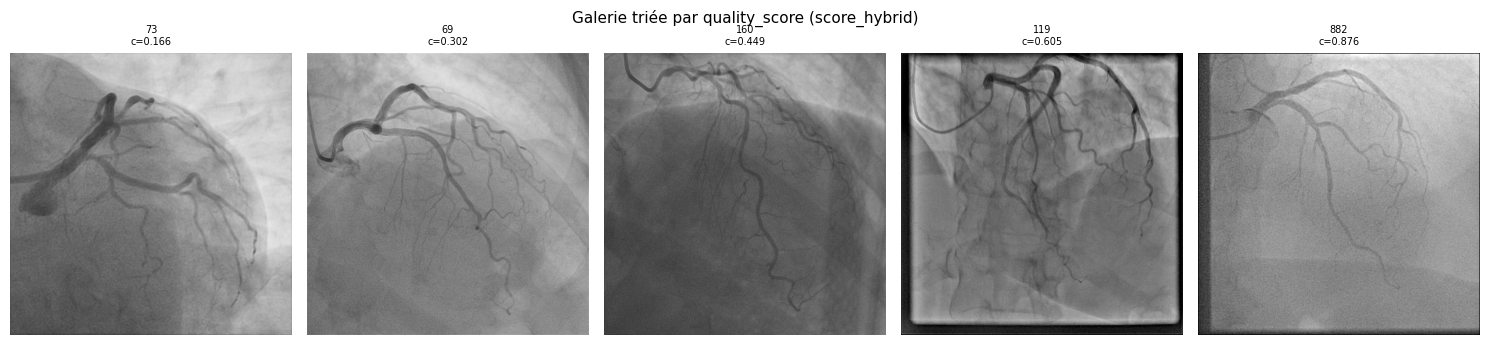

In [36]:
def load_gray(path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0


df_sorted = df_clipped.sort_values("quality_score").reset_index(drop=True)

# Sélectionner 5 images dans chaque quintile
N_COL  = 5
n_imgs = len(df_sorted)
quintile_indices = np.linspace(0, n_imgs - 1, N_COL, dtype=int)

fig, axes = plt.subplots(1, N_COL, figsize=(3 * N_COL, 3.5))

for col, idx in enumerate(quintile_indices):
    row_data = df_sorted.iloc[idx]
    try:
        img = load_gray(row_data["path"])
    except Exception:
        img = np.zeros((64, 64))
    axes[col].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[col].set_title(
        f"{str(row_data['image_id'])[:12]}\nc={row_data['quality_score']:.3f}",
        fontsize=7
    )
    axes[col].axis("off")

fig.suptitle(f"Galerie triée par quality_score ({FINAL_SCORE_COL})", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_gallery_sorted_by_score.png", dpi=120, bbox_inches="tight")
plt.show()

In [37]:
# Validation quantitative : corrélation du score final avec chaque métrique
print("Corrélation du score final avec les métriques brutes :")
for col in MEAN_COLS + ["spatial_homogeneity", "directional_balance"]:
    r = np.corrcoef(df_clipped["quality_score"].values,
                    df_clipped[col].values)[0, 1]
    bar = "▓" * int(abs(r) * 20)
    sign = "+" if r > 0 else "-"
    print(f"  {col:30s}  r={r:+.4f}  {sign}{bar}")

Corrélation du score final avec les métriques brutes :
  laplacian_var_mean              r=+0.8176  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  rms_contrast_mean               r=+0.9116  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  entropy_mean                    r=-0.1060  -▓▓
  tenengrad_mean                  r=+0.7863  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ten_H_mean                      r=+0.7475  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ten_V_mean                      r=+0.7511  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ten_D1_mean                     r=+0.8154  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ten_D2_mean                     r=+0.8031  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  spatial_homogeneity             r=-0.2783  -▓▓▓▓▓
  directional_balance             r=-0.6358  -▓▓▓▓▓▓▓▓▓▓▓▓


## 12. Seuillage en labels catégoriels

On divise le score en **3 classes** (tertiles) pour :
- La visualisation dans les notebooks suivants
- L'évaluation de robustesse du Notebook 5 (test sur les images "bad")

| Label | Tertile | Signification |
|---|---|---|
| `bad` | [0, 33%[ | Images avec artefacts sévères |
| `medium` | [33%, 67%[ | Qualité acceptable |
| `good` | [67%, 100%] | Images cliniquement exploitables |

In [38]:
t33 = df_clipped["quality_score"].quantile(1/3)
t67 = df_clipped["quality_score"].quantile(2/3)

def assign_label(score: float) -> str:
    if score < t33:
        return "bad"
    elif score < t67:
        return "medium"
    return "good"

df_clipped["quality_label"] = df_clipped["quality_score"].apply(assign_label)

print(f"Seuils  : bad < {t33:.4f} ≤ medium < {t67:.4f} ≤ good")
print("\nDistribution des labels :")
print(df_clipped["quality_label"].value_counts().to_string())

Seuils  : bad < 0.3306 ≤ medium < 0.5603 ≤ good

Distribution des labels :
quality_label
medium    400
good      400
bad       400


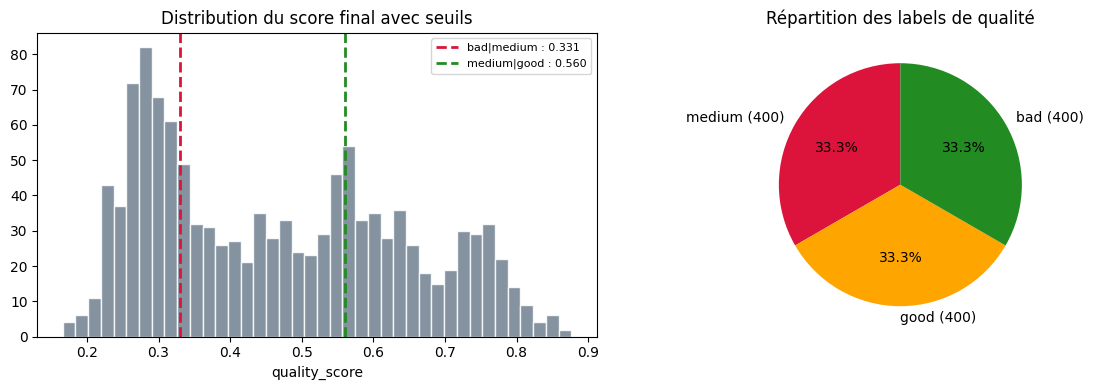

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution du score avec seuils
axes[0].hist(df_clipped["quality_score"], bins=40, color="slategray", edgecolor="white", alpha=0.85)
axes[0].axvline(t33, color="crimson",     lw=2, ls="--", label=f"bad|medium : {t33:.3f}")
axes[0].axvline(t67, color="forestgreen", lw=2, ls="--", label=f"medium|good : {t67:.3f}")
axes[0].set_title("Distribution du score final avec seuils")
axes[0].set_xlabel("quality_score")
axes[0].legend(fontsize=8)

# Camembert des labels
counts = df_clipped["quality_label"].value_counts()
axes[1].pie(
    counts.values,
    labels=[f"{l} ({n})" for l, n in counts.items()],
    colors=["crimson", "orange", "forestgreen"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Répartition des labels de qualité")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_label_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

## 13. Galerie good / bad / medium (9 exemples)

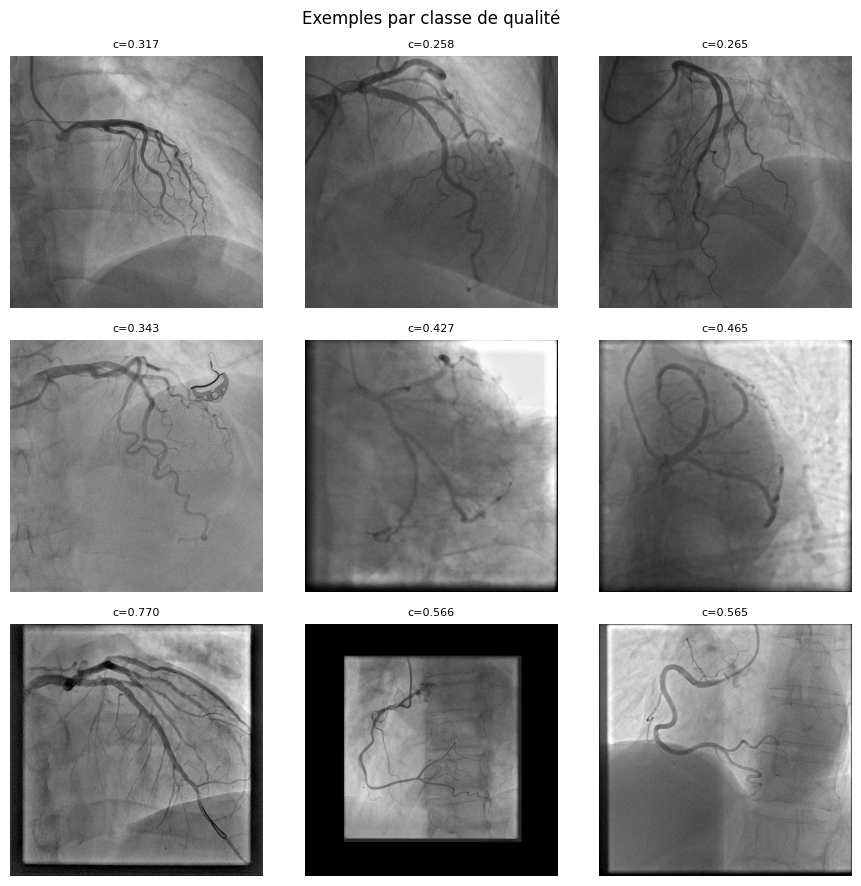

In [40]:
import random
random.seed(0)

N_PER_CLASS = 3
label_order = ["bad", "medium", "good"]
label_colors = {"bad": "crimson", "medium": "darkorange", "good": "forestgreen"}

fig, axes = plt.subplots(len(label_order), N_PER_CLASS, figsize=(3 * N_PER_CLASS, 3 * len(label_order)))

for row, label in enumerate(label_order):
    subset = df_clipped[df_clipped["quality_label"] == label]
    sample = subset.sample(min(N_PER_CLASS, len(subset)), random_state=row)
    for col, (_, r) in enumerate(sample.iterrows()):
        ax = axes[row, col]
        try:
            img = load_gray(r["path"])
        except Exception:
            img = np.zeros((64, 64))
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"c={r['quality_score']:.3f}", fontsize=8)
        if col == 0:
            ax.set_ylabel(label.upper(), color=label_colors[label], fontsize=10, fontweight="bold")
        ax.axis("off")

fig.suptitle("Exemples par classe de qualité", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_examples_per_class.png", dpi=120, bbox_inches="tight")
plt.show()

## 14. Export — `labels_quality.csv`

Ce fichier est le **pont entre ce travail et le Notebook 4** (modification de l'architecture MedVAE).

In [41]:
export_cols = [
    "image_id",
    "path",
    "quality_score",
    "quality_label",
    "score_weighted",
    "score_pca",
]
if USE_RESNET_SCORE:
    export_cols += ["score_resnet", "score_hybrid"]

df_export = df_clipped[export_cols].copy()
df_export.to_csv(OUT_LABELS_CSV, index=False)

print(f"Sauvegardé → {OUT_LABELS_CSV}")
print(f"Lignes     : {len(df_export)}")
print(f"Colonnes   : {export_cols}")
df_export.head(5)

Sauvegardé → outputs\labels_quality.csv
Lignes     : 1200
Colonnes   : ['image_id', 'path', 'quality_score', 'quality_label', 'score_weighted', 'score_pca', 'score_resnet', 'score_hybrid']


,image_id,path,quality_score,quality_label,score_weighted,score_pca,score_resnet,score_hybrid
0,1,C:\Users\theop\Documents\Telecom_Paris\2A\cour...,0.481270,medium,0.413409,0.341742,0.688658,0.481270
1,10,C:\Users\theop\Documents\Telecom_Paris\2A\cour...,0.485919,medium,0.368684,0.211145,0.877929,0.485919
2,100,C:\Users\theop\Documents\Telecom_Paris\2A\cour...,0.566607,good,0.453849,0.387754,0.858219,0.566607
3,1000,C:\Users\theop\Documents\Telecom_Paris\2A\cour...,0.679803,good,0.687425,0.751345,0.600638,0.679803
4,101,C:\Users\theop\Documents\Telecom_Paris\2A\cour...,0.392266,medium,0.454320,0.401947,0.320532,0.392266


In [42]:
# Vérification finale : statistiques par label
print("Statistiques du quality_score par label :")
print(df_export.groupby("quality_label")["quality_score"].describe().round(4).to_string())

Statistiques du quality_score par label :
               count    mean     std     min     25%     50%     75%     max
quality_label                                                               
bad            400.0  0.2754  0.0336  0.1663  0.2549  0.2785  0.3021  0.3300
good           400.0  0.6767  0.0801  0.5604  0.6050  0.6625  0.7441  0.8764
medium         400.0  0.4472  0.0711  0.3309  0.3829  0.4492  0.5071  0.5603


## Résumé du Notebook 3

| Étape | Résultat |
|---|---|
| Feature engineering | `spatial_homogeneity` + `directional_balance` |
| Méthode A | Score pondéré physique ∈ [0, 1] |
| Méthode B | PC1 normalisé (objectif, data-driven) |
| Méthode C (optionnelle) | Hybride A+B+ResNet-18 |
| Score final retenu | Décision automatique selon corrélation A↔B |
| Labels catégoriels | `bad` / `medium` / `good` (tertiles) |
| Export | `outputs/labels_quality.csv` |

**Prochain notebook :** `04_MedVAE_Architecture_Mod.ipynb` —  
Modifier le DataLoader et l'encodeur/décodeur MedVAE pour conditionner la génération sur `quality_score`.